# AudioSet-Tools Demo Notebook

This notebook demonstrates the `audioset_tools` package end to end.

The package supports three YouTube-backed metadata families:

- **AudioSet Standard**: weak-label CSV with `YTID`, `start_seconds`, `end_seconds`, and `positive_labels`.
- **AudioSet Strong**: strong-label TSV with `segment_id`, event time boundaries, and MID labels.
- **VGGSound**: CSV with `youtube_id`, `start_seconds`, a text label, and split.

The core design is simple: each source file is detected automatically and normalized into `AudioRecord` objects. All downstream functionality, including filtering, grouping, statistics, exports, event tracks, and download jobs, works through the same API.

This notebook is safe to run: it uses local metadata only, does not modify the original files under `datasets/`, and demonstrates the downloader in `dry_run` mode.


## 1. Workspace Setup

The following cell finds the repository root, enables local imports, and defines the paths to the metadata files used in this demo.


In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt

# Find the repository root even if Jupyter starts from a different working directory.
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
ROOT = next(path for path in candidates if (path / "taxonomy" / "audioset_tools").exists())

# Local imports for the refactored package and vendored py-salt.
sys.path.insert(0, str(ROOT / "taxonomy"))
sys.path.insert(0, str(ROOT / "taxonomy" / "salt" / "py-salt"))

from audioset_tools import (
    AUDIOSET,
    AUDIOSET_STRONG,
    VGGSOUND,
    AudioDataset,
    DownloadJob,
    SaltResolver,
    YouTubeDatasetDownloader,
    blacklist_labels,
    compute_stats,
    detect_format,
    filter_labels,
    find_samples_by_samples,
    find_samples_by_youtube_ids,
    generate_event_tracks,
    iter_events,
    load_dataset,
    load_label_map,
    merge_datasets,
    parse_metadata,
    plot_events_pianoroll,
    read_download_report,
    rebalance,
    select_range,
    write_download_report,
)

PATHS = {
    "audioset_eval": ROOT / "datasets" / "AudioSet_meta" / "eval_segments.csv",
    "audioset_labels": ROOT / "datasets" / "AudioSet_meta" / "class_labels_indices.csv",
    "strong_eval": ROOT / "datasets" / "AudioSet_Strong_meta" / "audioset_eval_strong.tsv",
    "strong_labels": ROOT / "datasets" / "AudioSet_Strong_meta" / "mid_to_display_name.tsv",
    "vggsound": ROOT / "datasets" / "VGGsound_meta" / "vggsound.csv",
}

OUTPUT_DIR = ROOT / "taxonomy" / "audioset_tools" / "tests" / "_demo_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Repository root:", ROOT)
print("Demo output directory:", OUTPUT_DIR)
for name, path in PATHS.items():
    print(f"{name:16s}", path.exists(), path.relative_to(ROOT))


Repository root: /Users/stefano/Documents/gpat_framework
Demo output directory: /Users/stefano/Documents/gpat_framework/taxonomy/audioset_tools/tests/_demo_outputs
audioset_eval    True datasets/AudioSet_meta/eval_segments.csv
audioset_labels  True datasets/AudioSet_meta/class_labels_indices.csv
strong_eval      True datasets/AudioSet_Strong_meta/audioset_eval_strong.tsv
strong_labels    True datasets/AudioSet_Strong_meta/mid_to_display_name.tsv
vggsound         True datasets/VGGsound_meta/vggsound.csv


## 2. Automatic Format Detection

`detect_format(...)` inspects each file schema and content. This removes the need for separate public APIs such as `filters_strong.py` or `re*` functions for already processed metadata.


In [2]:
for name in ["audioset_eval", "strong_eval", "vggsound"]:
    detected = detect_format(PATHS[name])
    print(f"{name:14s} -> {detected}")


audioset_eval  -> AudioSet
strong_eval    -> AudioSetStrong
vggsound       -> VggSound


## 3. Original Label Maps

AudioSet Standard and AudioSet Strong use IDs such as `/m/09x0r`. The package can load MID-to-display-name mappings from the official local metadata. VGGSound already stores text labels directly in its CSV file.


In [3]:
audioset_label_map = load_label_map(PATHS["audioset_labels"])
strong_label_map = load_label_map(PATHS["strong_labels"])

print("AudioSet label map size:", len(audioset_label_map))
print("AudioSet Strong label map size:", len(strong_label_map))
print("First AudioSet labels:")
for idx, (mid, label) in enumerate(audioset_label_map.items()):
    print(f"  {mid:12s} -> {label}")
    if idx == 4:
        break


AudioSet label map size: 527
AudioSet Strong label map size: 456
First AudioSet labels:
  /m/09x0r     -> Speech
  /m/05zppz    -> Male speech, man speaking
  /m/02zsn     -> Female speech, woman speaking
  /m/0ytgt     -> Child speech, kid speaking
  /m/01h8n0    -> Conversation


## 4. SALT Integration

`SaltResolver` is optional. Without SALT, the package still parses, filters, groups, exports, and generates download jobs using original labels. With SALT, each record can be enriched with standardized labels.

There are two modes:

1. `SaltResolver.from_mapping_file()` reads the local SALT assets directly. This is the lightweight path.
2. `SaltResolver.from_py_salt()` uses `py_salt.EventExplorer`, which is useful when you want to stay inside the py-salt workflow.


In [4]:
salt = SaltResolver.from_mapping_file()
print("SALT resolver loaded from mapping file.")
print("SALT descendants of 'vehicle' (first 20):")
print(salt.descendants("vehicle")[:20])
print()
print("Direct resolution examples:")
print("AudioSet / Siren ->", salt.resolve(AUDIOSET, ["Siren"]))
print("AudioSetStrong / Police car (siren) ->", salt.resolve(AUDIOSET_STRONG, ["Police car (siren)"]))
print("VggSound / car engine starting ->", salt.resolve(VGGSOUND, ["car engine starting"]))


SALT resolver loaded from mapping file.
SALT descendants of 'vehicle' (first 20):
('snowmobile', 'tractor', 'road_vehicle', 'emergency_vehicle', 'vehicle_engine', 'bus_engine', 'car_engine', 'motorcycle_engine', 'truck_engine', 'heavy_engine_(low_frequency)', 'car', 'power_windows_electric windows', 'car_skidding', 'tire_squealing', 'race_car', 'car_passing_by', 'motorcycle', 'large_vehicle', 'truck', 'cleaning_truck')

Direct resolution examples:
AudioSet / Siren -> ('alarm_signal', 'siren_ringing', 'sound_of_things')
AudioSetStrong / Police car (siren) -> ('alarm_signal', 'emergency_vehicle', 'police_car_siren_ringing', 'road_vehicle', 'siren_ringing', 'sound_of_things', 'vehicle', 'vehicle_siren_ringing')
VggSound / car engine starting -> ('engine', 'engine_starting', 'sound_of_things')


### 4.1 Integration Through `py_salt`

This cell demonstrates direct integration with `py_salt`. If `py_salt` is not installed or importable, the recommended fallback remains `from_mapping_file()`.


In [5]:
try:
    salt_from_py_salt = SaltResolver.from_py_salt()
    print("SaltResolver.from_py_salt() OK")
    print("VggSound / people marching ->", salt_from_py_salt.resolve(VGGSOUND, ["people marching"]))
except Exception as exc:
    print("py_salt integration is not available in this environment:")
    print(type(exc).__name__, exc)


SaltResolver.from_py_salt() OK
VggSound / people marching -> ('footsteps', 'human_movement', 'human_sounds', 'walking')


## 5. Normalized Parsing of the Three Datasets

`AudioDataset.from_file(...)` creates a sequence of `AudioRecord` objects. Each record preserves:

- source dataset;
- source ID;
- YouTube ID;
- clip time interval;
- original label IDs, when available;
- original text labels;
- SALT labels, when a `SaltResolver` is provided;
- temporal events, for AudioSet Strong;
- raw metadata, for traceability.


In [6]:
audioset = AudioDataset.from_file(
    PATHS["audioset_eval"],
    labels_file=PATHS["audioset_labels"],
    salt_resolver=salt,
)

strong = AudioDataset.from_file(
    PATHS["strong_eval"],
    labels_file=PATHS["strong_labels"],
    salt_resolver=salt,
)

vgg = AudioDataset.from_file(
    PATHS["vggsound"],
    salt_resolver=salt,
)

print("AudioSet records:", len(audioset))
print("AudioSet Strong normalized segments:", len(strong))
print("VGGSound records:", len(vgg))


AudioSet records: 20371
AudioSet Strong normalized segments: 16996
VGGSound records: 199467


In [7]:
def record_preview(record):
    return {
        "dataset": record.dataset,
        "source_id": record.source_id,
        "youtube_id": record.youtube_id,
        "start_seconds": record.start_seconds,
        "end_seconds": record.end_seconds,
        "original_label_ids": record.original_label_ids[:5],
        "original_labels": record.original_labels[:5],
        "salt_labels": record.salt_labels[:8],
        "split": record.split,
        "events": len(record.events),
    }

pd.DataFrame([
    record_preview(audioset[0]),
    record_preview(strong[0]),
    record_preview(vgg[0]),
])


,dataset,source_id,youtube_id,start_seconds,end_seconds,original_label_ids,original_labels,salt_labels,split,events
0,AudioSet,--4gqARaEJE_0_10,--4gqARaEJE,0.0,10.0,"(/m/068hy, /m/07q6cd_, /m/0bt9lr, /m/0jbk)","(Domestic animals, pets, Squeak, Dog, Animal)","(animal, domestic_animal, onomatopoeia, source...",None,0
1,AudioSetStrong,s9d-2nhuJCQ_30000,s9d-2nhuJCQ,30.0,40.0,"(/m/04rlf, /m/053hz1, /m/03qtwd, /m/01w250, /m...","(Music, Cheering, Crowd, Whistling, Clapping)","(music, crowd, human_group_actions, human_soun...",None,6
2,VggSound,---g-f_I2yQ_1,---g-f_I2yQ,1.0,11.0,(),"(people marching,)","(footsteps, human_movement, human_sounds, walk...",test,0


## 6. Low-Level Parsing With `parse_metadata(...)`

`AudioDataset` is the recommended API, but `parse_metadata(...)` is still available when you only need a list of normalized records.


In [8]:
first_three = parse_metadata(
    PATHS["audioset_eval"],
    labels_file=PATHS["audioset_labels"],
    salt_resolver=salt,
)[:3]

for record in first_three:
    print(record.source_id, record.original_labels, "=>", record.salt_labels[:5])


--4gqARaEJE_0_10 ('Domestic animals, pets', 'Squeak', 'Dog', 'Animal') => ('animal', 'domestic_animal', 'onomatopoeia', 'source-ambiguous_sounds', 'squeak')
--BfvyPmVMo_20_30 ('Hammer',) => ('hammering', 'machinery_impact', 'sound_of_things', 'tools')
--U7joUcTCo_0_10 ('Cough',) => ('coughing', 'human_non-speech_sounds', 'human_sounds')


## 7. Label Statistics and Inspection

`summary()` and `label_counts(...)` provide a quick view of metadata composition.


In [9]:
summary_rows = []
for name, dataset in [("AudioSet", audioset), ("AudioSet Strong", strong), ("VGGSound", vgg)]:
    summary = dataset.summary()
    summary_rows.append({
        "dataset": name,
        "records": summary["records"],
        "unique_youtube_ids": summary["unique_youtube_ids"],
        "top_original_label": dataset.label_counts("original").most_common(1)[0],
        "top_salt_label": dataset.label_counts("salt").most_common(1)[0] if dataset.label_counts("salt") else None,
    })

pd.DataFrame(summary_rows)


,dataset,records,unique_youtube_ids,top_original_label,top_salt_label
0,AudioSet,20371,20371,"(Music, 5695)","(sound_of_things, 8148)"
1,AudioSet Strong,16996,16996,"(Music, 6911)","(human_sounds, 10418)"
2,VGGSound,199467,161810,"(female speech, woman speaking, 1050)","(sound_of_things, 61523)"


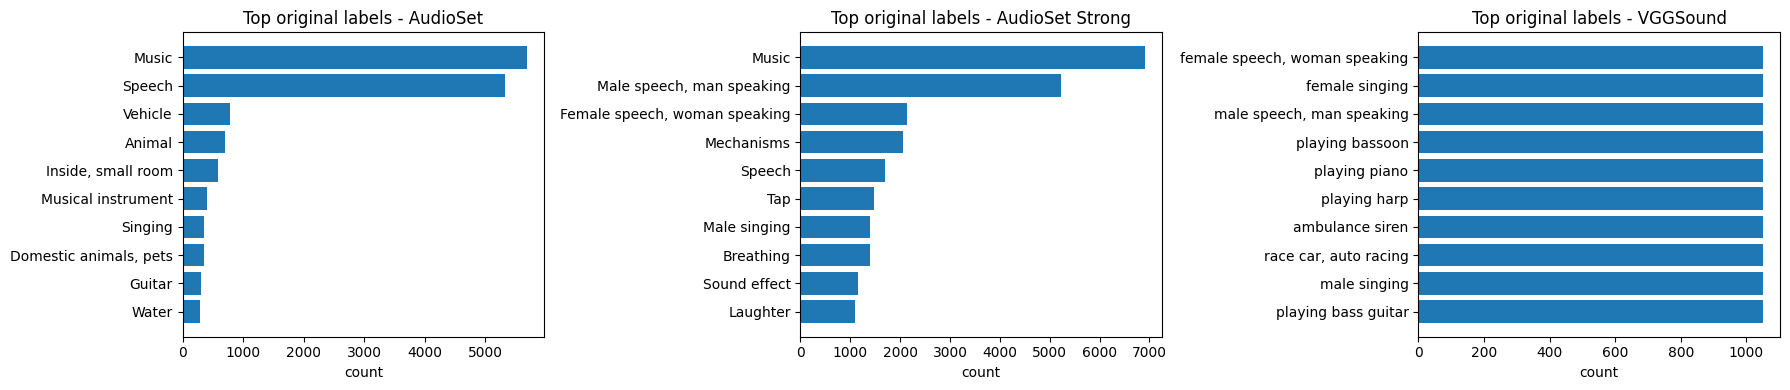

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (title, dataset) in zip(
    axes,
    [("AudioSet", audioset), ("AudioSet Strong", strong), ("VGGSound", vgg)],
):
    counts = dataset.label_counts("original").most_common(10)
    labels = [item[0] for item in counts]
    values = [item[1] for item in counts]
    ax.barh(labels[::-1], values[::-1])
    ax.set_title(f"Top original labels - {title}")
    ax.set_xlabel("count")
plt.tight_layout()
plt.show()


## 8. One Filtering API: Original Labels, IDs, and SALT Labels

`filter_labels(...)` works through the same API for all datasets.

Key parameters:

- `label_space='original'`: source text labels;
- `label_space='id'`: original IDs such as AudioSet MIDs;
- `label_space='salt'`: standardized SALT labels;
- `match='any'`, `'all'`, or `'none'`;
- `include_descendants=True`: expands SALT labels such as `vehicle` to more specific descendants.


In [11]:
speech_original = audioset.filter_labels(["Speech"], label_space="original")
speech_by_mid = audioset.filter_labels(["/m/09x0r"], label_space="id")
vehicle_salt_audioset = audioset.filter_labels(
    ["vehicle"],
    label_space="salt",
    include_descendants=True,
)
vehicle_salt_vgg = vgg.filter_labels(
    ["vehicle"],
    label_space="salt",
    include_descendants=True,
)
not_speech = audioset.filter_labels(["Speech"], label_space="original", match="none")

print("AudioSet Speech by original label:", len(speech_original))
print("AudioSet Speech by MID:", len(speech_by_mid))
print("AudioSet vehicle by SALT descendants:", len(vehicle_salt_audioset))
print("VGGSound vehicle by SALT descendants:", len(vehicle_salt_vgg))
print("AudioSet records without Speech:", len(not_speech))


AudioSet Speech by original label: 5324
AudioSet Speech by MID: 5324
AudioSet vehicle by SALT descendants: 2013
VGGSound vehicle by SALT descendants: 22772
AudioSet records without Speech: 15047


In [12]:
# Equivalent functional helper built on top of AudioDataset, useful for compact scripts.
functional_vehicle = filter_labels(
    PATHS["vggsound"],
    ["vehicle"],
    salt_resolver=salt,
    label_space="salt",
    include_descendants=True,
)
functional_no_vehicle = blacklist_labels(
    vgg,
    ["vehicle"],
    label_space="salt",
    include_descendants=True,
)

print("Functional filter_labels VGG vehicle:", len(functional_vehicle))
print("Functional blacklist_labels VGG non-vehicle:", len(functional_no_vehicle))
print("sum:", len(functional_vehicle) + len(functional_no_vehicle), "vs total", len(vgg))


Functional filter_labels VGG vehicle: 22772
Functional blacklist_labels VGG non-vehicle: 176695
sum: 199467 vs total 199467


## 9. Range Selection, Grouping, and YouTube-ID Lookup

These functions replace older helpers such as `select_by_samp_idx` and `find_samps_by_samps`, while working on all normalized supported formats.


In [13]:
small_vgg = vgg.select_range(0, 10)
print("First 10 VGG records:", len(small_vgg))
print([record.source_id for record in small_vgg[:3]])

vgg_by_split = vgg.group_by("split")
print("VGGSound split sizes:")
for split, split_dataset in vgg_by_split.items():
    print(f"  {split:5s}: {len(split_dataset)}")

first_ids = [record.youtube_id for record in small_vgg[:3]]
found = find_samples_by_youtube_ids(vgg, first_ids)
print("Lookup by YouTube IDs:", first_ids, "->", len(found), "records")


First 10 VGG records: 10
['---g-f_I2yQ_1', '--0PQM4-hqg_30', '--56QUhyDQM_185']
VGGSound split sizes:
  test : 15496
  train: 183971
Lookup by YouTube IDs: ['---g-f_I2yQ', '--0PQM4-hqg', '--56QUhyDQM'] -> 3 records


In [14]:
# Find records in one dataset using the YouTube IDs contained in another dataset.
# Here we use small samples to keep the example readable.
source_sample = vgg.select_range(0, 5)
target_sample = vgg.select_range(0, 50)
matched = find_samples_by_samples(source_sample, target_sample)
print("Source IDs:", [record.youtube_id for record in source_sample])
print("Matched records in target:", len(matched))


Source IDs: ['---g-f_I2yQ', '--0PQM4-hqg', '--56QUhyDQM', '--5OkAjCI7g', '--8puiAGLhs']
Matched records in target: 5


## 10. Merge, Deduplication, and Rebalancing

`merge_datasets(...)` concatenates normalized datasets and removes duplicates. `rebalance(...)` performs undersampling toward the smallest label bucket while preserving unique records.


In [15]:
merged = merge_datasets(vgg.select_range(0, 5), vgg.select_range(3, 8))
print("Merge 0:5 + 3:8 with dedup:", len(merged))
print([record.source_id for record in merged])

# Rebalance two VGGSound classes selected from the local metadata.
focus = ["car engine starting", "wind noise"]
focused = vgg.filter_labels(focus, label_space="original")
balanced = focused.rebalance(focus_labels=focus, label_space="original", random_state=0)
print("Focused counts:", focused.label_counts("original").most_common())
print("Balanced counts:", balanced.label_counts("original").most_common())
print("Balanced records:", len(balanced))

# Equivalent functional helper.
balanced_helper = rebalance(focused, focus_labels=focus, label_space="original", random_state=0)
print("Helper rebalance records:", len(balanced_helper))


Merge 0:5 + 3:8 with dedup: 8
['---g-f_I2yQ_1', '--0PQM4-hqg_30', '--56QUhyDQM_185', '--5OkAjCI7g_40', '--8puiAGLhs_30', '--96EN9NUQM_242', '--9O4XZOge4_30', '--Aa4M484QM_0']


Focused counts: [('wind noise', 922), ('car engine starting', 491)]
Balanced counts: [('car engine starting', 491), ('wind noise', 491)]
Balanced records: 982
Helper rebalance records: 982


## 11. Normalized JSON/CSV Export

Exports are derived artifacts, so they do not touch the original metadata. They are useful for reproducible caches or subsets.


In [16]:
subset = vehicle_salt_vgg.select_range(0, 5)
json_path = OUTPUT_DIR / "vgg_vehicle_subset.normalized.json"
csv_path = OUTPUT_DIR / "vgg_vehicle_subset.normalized.csv"
subset.to_json(json_path)
subset.to_csv(csv_path)

print("JSON written:", json_path.relative_to(ROOT), json_path.stat().st_size, "bytes")
print("CSV written:", csv_path.relative_to(ROOT), csv_path.stat().st_size, "bytes")
print("JSON preview:")
with json_path.open() as handle:
    preview = json.load(handle)[:1]
print(json.dumps(preview, indent=2)[:1000])


JSON written: taxonomy/audioset_tools/tests/_demo_outputs/vgg_vehicle_subset.normalized.json 3445 bytes
CSV written: taxonomy/audioset_tools/tests/_demo_outputs/vgg_vehicle_subset.normalized.csv 1109 bytes
JSON preview:
[
  {
    "dataset": "VggSound",
    "source_id": "--SvivLlKLU_137",
    "youtube_id": "--SvivLlKLU",
    "start_seconds": 137.0,
    "end_seconds": 147.0,
    "original_label_ids": [],
    "original_labels": [
      "airplane"
    ],
    "salt_labels": [
      "aircraft",
      "airplane",
      "sound_of_things",
      "vehicle"
    ],
    "split": "train",
    "events": [],
    "raw": {
      "youtube_id": "--SvivLlKLU",
      "start_seconds": "137",
      "label": "airplane",
      "split": "train"
    },
    "source_path": "/Users/stefano/Documents/gpat_framework/datasets/VGGsound_meta/vggsound.csv"
  }
]


## 12. AudioSet Strong: Temporal Events, Tracks, and Piano Roll

AudioSet Strong is normalized by segment. Each `AudioRecord` contains a list of `TemporalEvent` objects. Event utilities operate on `AudioDataset`, not on a separate `_strong` module.


In [17]:
strong_one = strong.select_range(0, 1)
record = strong_one[0]
print("Segment:", record.source_id)
print("YouTube ID:", record.youtube_id)
print("Clip interval:", record.start_seconds, record.end_seconds)
print("Events:", len(record.events))

pd.DataFrame([
    {
        "start": event.start_seconds,
        "end": event.end_seconds,
        "label_id": event.original_label_id,
        "label": event.original_label,
        "salt_labels": event.salt_labels,
    }
    for event in record.events
])


Segment: s9d-2nhuJCQ_30000
YouTube ID: s9d-2nhuJCQ
Clip interval: 30.0 40.0
Events: 6


,start,end,label_id,label,salt_labels
0,0.000,10.000,/m/04rlf,Music,"(music,)"
1,2.627,7.237,/m/053hz1,Cheering,"(crowd, human_group_actions, human_sounds, peo..."
2,2.627,9.239,/m/03qtwd,Crowd,"(crowd, human_group_actions, human_sounds)"
3,5.634,6.649,/m/01w250,Whistling,"(human_non-speech_sounds, human_sounds, whistl..."
4,7.201,8.560,/m/0l15bq,Clapping,"(clapping, hands, human_non-speech_sounds, hum..."
5,8.089,9.230,/m/01w250,Whistling,"(human_non-speech_sounds, human_sounds, whistl..."


Number of event tracks: 5
s9d-2nhuJCQ_30000_Music shape= (20,) active_bins= 20
s9d-2nhuJCQ_30000_Cheering shape= (20,) active_bins= 10
s9d-2nhuJCQ_30000_Crowd shape= (20,) active_bins= 14
s9d-2nhuJCQ_30000_Whistling shape= (20,) active_bins= 6
s9d-2nhuJCQ_30000_Clapping shape= (20,) active_bins= 4


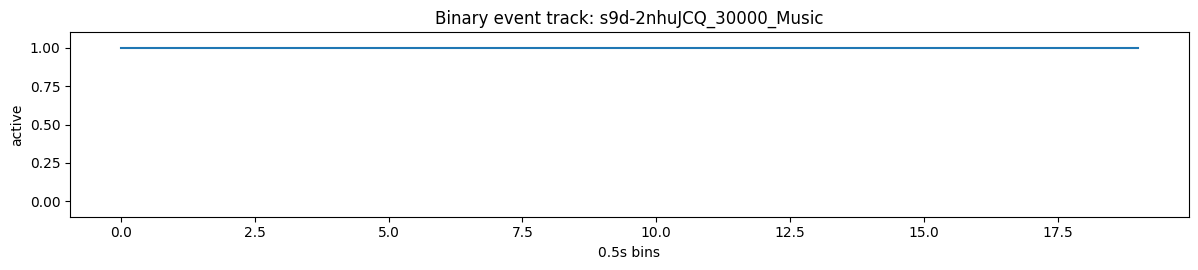

In [18]:
tracks = generate_event_tracks(strong_one, bin_size=0.5, label_space="original")
print("Number of event tracks:", len(tracks))
for key, track in tracks[:5]:
    print(key, "shape=", track.shape, "active_bins=", int(track.sum()))

fig, ax = plt.subplots(figsize=(12, 2.8))
if tracks:
    key, track = tracks[0]
    ax.step(range(len(track)), track, where="post")
    ax.set_title(f"Binary event track: {key}")
    ax.set_xlabel("0.5s bins")
    ax.set_ylabel("active")
    ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()


Piano-roll figures generated: 1


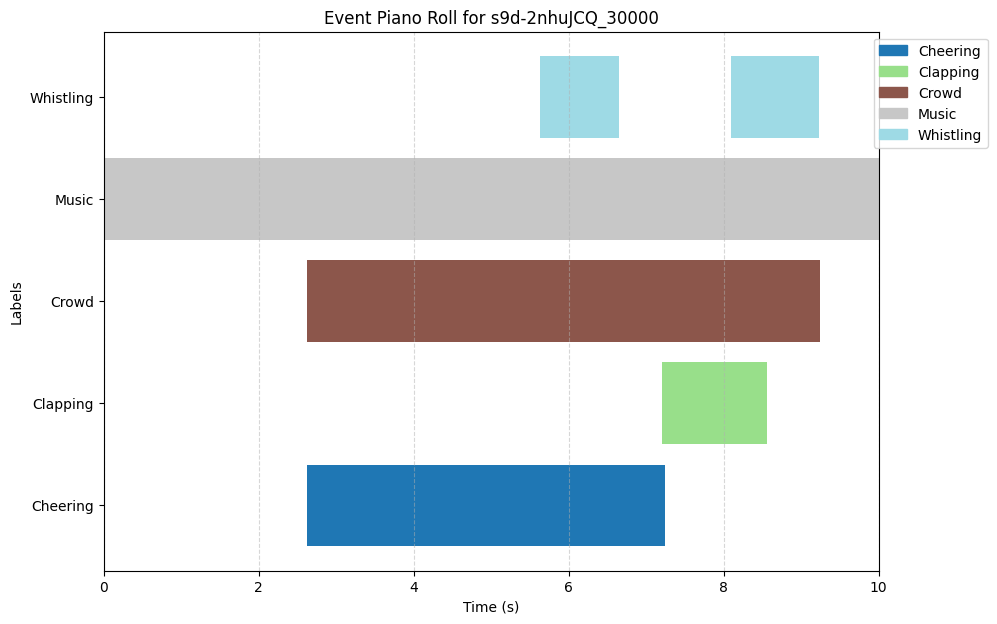

In [19]:
figures = plot_events_pianoroll(strong_one, label_space="original", save_plots=False)
print("Piano-roll figures generated:", len(figures))
plt.show()


## 13. Download Jobs and Dry-Run Downloader

`to_download_jobs()` converts normalized records into download requests. Real downloading uses `yt-dlp`, `soundfile`, and `resampy`, and requires `ffmpeg` installed at system level.

This demo uses `dry_run=True`, so no network access is performed.


In [20]:
jobs = vgg.select_range(0, 3).to_download_jobs()
for job in jobs:
    print(job)


DownloadJob(dataset='VggSound', source_id='---g-f_I2yQ_1', youtube_id='---g-f_I2yQ', start_seconds=1.0, end_seconds=11.0, output_stem='---g-f_I2yQ_1', original_label_ids=(), original_labels=('people marching',), salt_labels=('footsteps', 'human_movement', 'human_sounds', 'walking'), metadata={'split': 'test', 'source_path': '/Users/stefano/Documents/gpat_framework/datasets/VGGsound_meta/vggsound.csv'})
DownloadJob(dataset='VggSound', source_id='--0PQM4-hqg_30', youtube_id='--0PQM4-hqg', start_seconds=30.0, end_seconds=40.0, output_stem='--0PQM4-hqg_30', original_label_ids=(), original_labels=('waterfall burbling',), salt_labels=('natural_sounds', 'water', 'water_natural', 'waterfall'), metadata={'split': 'train', 'source_path': '/Users/stefano/Documents/gpat_framework/datasets/VGGsound_meta/vggsound.csv'})
DownloadJob(dataset='VggSound', source_id='--56QUhyDQM_185', youtube_id='--56QUhyDQM', start_seconds=185.0, end_seconds=195.0, output_stem='--56QUhyDQM_185', original_label_ids=(), o

In [21]:
downloader = YouTubeDatasetDownloader(
    output_dir=OUTPUT_DIR / "downloads",
    target_sr=44100,
    channels="mono",
    normalize=True,
    dry_run=True,
)

report_entries = downloader.download_jobs(
    jobs,
    report_path=OUTPUT_DIR / "download_report.dry_run.json",
)

pd.DataFrame([entry.to_dict() for entry in report_entries])


,dataset,source_id,youtube_id,start_seconds,end_seconds,requested_output_path,final_output_path,status,success,error_category,error_message,retry_count,processing_timestamp,original_label_ids,original_labels,salt_labels
0,VggSound,---g-f_I2yQ_1,---g-f_I2yQ,1.0,11.0,/Users/stefano/Documents/gpat_framework/taxono...,None,skipped_dry_run,True,None,None,0,2026-07-11T07:24:47.802387+00:00,(),"(people marching,)","(footsteps, human_movement, human_sounds, walk..."
1,VggSound,--0PQM4-hqg_30,--0PQM4-hqg,30.0,40.0,/Users/stefano/Documents/gpat_framework/taxono...,None,skipped_dry_run,True,None,None,0,2026-07-11T07:24:47.802421+00:00,(),"(waterfall burbling,)","(natural_sounds, water, water_natural, waterfall)"
2,VggSound,--56QUhyDQM_185,--56QUhyDQM,185.0,195.0,/Users/stefano/Documents/gpat_framework/taxono...,None,skipped_dry_run,True,None,None,0,2026-07-11T07:24:47.802438+00:00,(),"(playing tennis,)","(human_activities, playing_tennis)"


In [22]:
report_path = OUTPUT_DIR / "download_report.dry_run.json"
loaded_report = read_download_report(report_path)
print("Report entries:", len(loaded_report))
print(json.dumps(loaded_report[0], indent=2))


Report entries: 3
{
  "dataset": "VggSound",
  "source_id": "---g-f_I2yQ_1",
  "youtube_id": "---g-f_I2yQ",
  "start_seconds": 1.0,
  "end_seconds": 11.0,
  "requested_output_path": "/Users/stefano/Documents/gpat_framework/taxonomy/audioset_tools/tests/_demo_outputs/downloads/---g-f_I2yQ_1.wav",
  "final_output_path": null,
  "status": "skipped_dry_run",
  "success": true,
  "error_category": null,
  "error_message": null,
  "retry_count": 0,
  "processing_timestamp": "2026-07-11T07:24:47.802387+00:00",
  "original_label_ids": [],
  "original_labels": [
    "people marching"
  ],
  "salt_labels": [
    "footsteps",
    "human_movement",
    "human_sounds",
    "walking"
  ]
}


### 13.1 Malformed Metadata: Structured Reporting

The downloader should not build unsafe shell commands or fail opaquely. A malformed YouTube ID is caught and reported as a structured error.


In [23]:
invalid_job = DownloadJob(dataset=VGGSOUND, source_id="bad-row", youtube_id="not-valid")
invalid_report = downloader.download_job(invalid_job)
print(json.dumps(invalid_report.to_dict(), indent=2))


{
  "dataset": "VggSound",
  "source_id": "bad-row",
  "youtube_id": "not-valid",
  "start_seconds": null,
  "end_seconds": null,
  "requested_output_path": "/Users/stefano/Documents/gpat_framework/taxonomy/audioset_tools/tests/_demo_outputs/downloads/bad-row.wav",
  "final_output_path": null,
  "status": "invalid_metadata",
  "success": false,
  "error_category": "InvalidYouTubeId",
  "error_message": "Malformed YouTube ID: not-valid",
  "retry_count": 0,
  "processing_timestamp": "2026-07-11T07:24:47.818530+00:00",
  "original_label_ids": [],
  "original_labels": [],
  "salt_labels": []
}


## 14. Functional API vs Object-Oriented API

The package exposes both styles:

- **Object-oriented**: `AudioDataset.from_file(...).filter_labels(...).group_by(...)`.
- **Functional**: `filter_labels(path_or_dataset, ...)`, `compute_stats(...)`, `select_range(...)`.

The object-oriented style is recommended for longer workflows; the functional style is convenient in compact scripts.


In [24]:
# Object-oriented
obj_result = (
    AudioDataset.from_file(PATHS["vggsound"], salt_resolver=salt)
    .filter_labels(["vehicle"], label_space="salt", include_descendants=True)
    .select_range(0, 5)
)

# Functional
fn_result = select_range(
    filter_labels(
        PATHS["vggsound"],
        ["vehicle"],
        salt_resolver=salt,
        label_space="salt",
        include_descendants=True,
    ),
    0,
    5,
)

print("Object-oriented source IDs:")
print([record.source_id for record in obj_result])
print("Functional source IDs:")
print([record.source_id for record in fn_result])
print("Same result:", [r.source_id for r in obj_result] == [r.source_id for r in fn_result])


Object-oriented source IDs:
['--SvivLlKLU_137', '--SvivLlKLU_662', '--TKJIv9aY4_210', '--TKJIv9aY4_282', '--byNAHo7tQ_0']
Functional source IDs:
['--SvivLlKLU_137', '--SvivLlKLU_662', '--TKJIv9aY4_210', '--TKJIv9aY4_282', '--byNAHo7tQ_0']
Same result: True


## 15. Complete Mini Workflow: SALT-Aware Vehicle Subset

This cell combines parsing, SALT, filtering, statistics, export, and download-job generation for a small VGGSound subset related to vehicles.


In [25]:
vehicle_subset = (
    load_dataset(PATHS["vggsound"], salt_resolver=salt)
    .filter_labels(["vehicle"], label_space="salt", include_descendants=True)
    .select_range(0, 20)
)

stats = compute_stats(vehicle_subset)
vehicle_subset_path = OUTPUT_DIR / "vehicle_subset_20.json"
vehicle_subset.to_json(vehicle_subset_path)
vehicle_jobs = vehicle_subset.to_download_jobs()

print("Records:", stats["records"])
print("Unique YouTube IDs:", stats["unique_youtube_ids"])
print("Top original labels:", vehicle_subset.label_counts("original").most_common(10))
print("Top SALT labels:", vehicle_subset.label_counts("salt").most_common(10))
print("Export:", vehicle_subset_path.relative_to(ROOT))
print("Download jobs:", len(vehicle_jobs))


Records: 20
Unique YouTube IDs: 17
Top original labels: [('car passing by', 3), ('vehicle horn, car horn, honking', 3), ('airplane', 2), ('ambulance siren', 2), ('race car, auto racing', 2), ('subway, metro, underground', 1), ('driving buses', 1), ('motorboat, speedboat acceleration', 1), ('fire truck siren', 1), ('rowboat, canoe, kayak rowing', 1)]
Top SALT labels: [('sound_of_things', 20), ('vehicle', 20), ('road_vehicle', 13), ('car', 8), ('engine', 7), ('vehicle_engine', 7), ('alarm_signal', 6), ('car_engine', 5), ('emergency_vehicle', 3), ('siren_ringing', 3)]
Export: taxonomy/audioset_tools/tests/_demo_outputs/vehicle_subset_20.json
Download jobs: 20


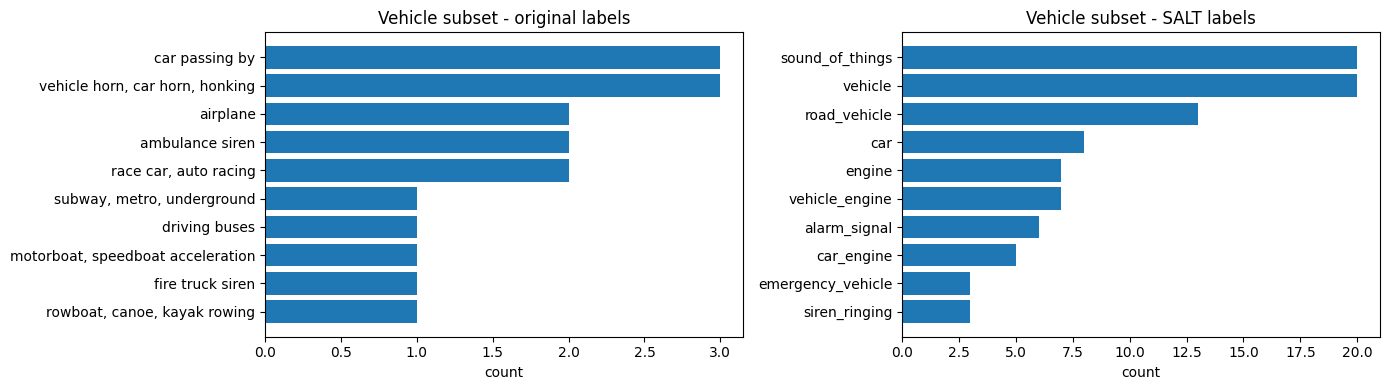

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, label_space, title in [
    (axes[0], "original", "Vehicle subset - original labels"),
    (axes[1], "salt", "Vehicle subset - SALT labels"),
]:
    counts = vehicle_subset.label_counts(label_space).most_common(10)
    labels = [item[0] for item in counts]
    values = [item[1] for item in counts]
    ax.barh(labels[::-1], values[::-1])
    ax.set_title(title)
    ax.set_xlabel("count")
plt.tight_layout()
plt.show()


## 16. Operational Summary

The main demonstrated capabilities are:

- automatic format detection;
- normalized parsing of AudioSet Standard, AudioSet Strong, and VGGSound;
- original label-map loading;
- lightweight SALT integration and py-salt-backed integration;
- filtering in original, ID, and SALT label spaces;
- blacklisting through `match='none'` or `blacklist_labels(...)`;
- range selection, grouping, and YouTube-ID matching;
- merge, deduplication, and rebalancing;
- statistics and plots;
- event tracks and piano-roll plots for AudioSet Strong;
- normalized JSON/CSV export;
- download-job generation;
- dry-run downloader and structured JSON reports.

The official metadata under `datasets/` remains immutable; any demo artifact is written under `taxonomy/audioset_tools/tests/_demo_outputs`.
